# 4 - Temporal — Frequência, sazonalidade e tendência

## Objetivo

Investigar o **eixo temporal** do dataset: frequência de coleta, sazonalidade (mensal/anual), tendências de longo prazo e autocorrelação por variável. Decide se features temporais derivadas (`Mês`, `Estação_do_Ano`, `Ano`, `dias_desde_inicio`) terão valor preditivo para a GAIN e se a irregularidade da amostragem inviabiliza modelos sequenciais (LSTM/TimeGAN).

## Pergunta que responde

> Há padrão temporal explorável? Quais features derivadas vão alimentar a GAIN?

## Posição na Etapa 1 — EDA

Notebook **4 de 6**. Responde à quarta das 5 perguntas-meta:

1. Quais variáveis têm boa cobertura e quais são críticas? → `01_descritivo.ipynb`
2. Quais variáveis são simétricas vs assimétricas? → `02_distribuicoes.ipynb`
3. Quais pares são correlacionados? → `03_correlacoes.ipynb`
4. **Há padrão temporal?** ← *este notebook*
5. As estações são distintas? → `05_estacoes.ipynb`
6. A censura é estruturada? → `06_lds.ipynb`

## Hipótese

O Rio de Janeiro tem dois regimes climáticos bem definidos: **úmido (nov–mar)** com chuvas intensas que aumentam escoamento urbano (mais Turbidez, Coliformes, Nutrientes) e **seco (abr–out)** com águas mais claras e maior insolação (mais fotossíntese → mais Cianobactérias?). Esperamos:

- **Sazonalidade clara em Temperatura da Água** (mais quente nov–mar).
- **Pico de Turbidez/Coliformes/Nutrientes** nos meses chuvosos.
- **Pico de Cianobactérias/Microcistinas** no fim do verão (água quente + nutrientes residuais).
- **Coleta nominal mensal**, mas com irregularidades (gaps, paralisações).

## Resumo executivo

- **Cobertura temporal:** 2012–2025 (14 anos), 657 coletas. Esforço amostral irregular: pico em 2016 (99 coletas), colapso em 2020 (6 — COVID), recuperação em 2025 (60).
- **Coleta nominalmente mensal** — gap mediano entre 36 e 48 dias por estação. Mas a cauda é longa: 6 estações têm pelo menos um gap de ~365 dias (provavelmente o vazio de 2020).
- **Sazonalidade significativa em 11 de 13 variáveis** (Kruskal-Wallis por mês, p < 0,05). Apenas **Turbidez** (p = 0,067) e **Coliformes Termotolerantes** (p = 0,22) não passam — dominadas por eventos esporádicos, não por estação do ano.
- **Temperatura da Água é o sinal sazonal mais forte** (H = 353, ACF[12] = +0,43 e ACF[6] = −0,54 em MR369 — assinatura cosseno anual perfeita).
- **Tendências de longo prazo existem mas são fracas** (|ρ_Spearman vs tempo| < 0,27 em todas as variáveis). Estatisticamente significativas pelo n grande, mas magnitude pequena: o sistema lagunar é razoavelmente estacionário no horizonte 2012–2025. Destaque para **queda de Cianobactérias** (ρ = −0,25) e **alta de OD** (ρ = +0,14).
- **Decisão arquitetural:** a irregularidade da amostragem (gaps até 1 ano, 2020 quase vazio, JC341/MR363 com < 12 amostras) **inviabiliza modelos sequenciais puros** (TimeGAN, LSTM-imputer). Confirma a escolha de **GAIN tabular com features temporais derivadas**: `mes_sin`, `mes_cos`, `estacao_do_ano` (úmido/seco), `ano_norm`, `dias_desde_inicio`.

## Setup

Imports + `statsmodels.tsa.stattools` para ACF/PACF. Caminhos relativos a `Code/2 - EDA/04_temporal.ipynb`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import acf, pacf

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH   = Path("../../Data/IntermediaryData/WaterQualityInitialData.xlsx")
OUTPUT_BASE = Path("../../Data/Figures/01_EDA")
FIG_DIR     = OUTPUT_BASE / "figuras"
TAB_DIR     = OUTPUT_BASE / "tabelas"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

VARS = [
    "DBO", "OD", "Nitrato", "Nitrogênio Amoniacal Total", "Fósforo Total",
    "Condutividade", "pH", "Turbidez", "Temperatura da Água",
    "Sólidos Suspensos Totais", "Coliformes Termotolerantes",
    "Cianobacterias", "Microcistinas",
]

STATIONS = ["JC341", "JC342", "CM320", "MR361", "MR363", "MR369", "TJ303", "TJ306"]

# Estação central usada para séries temporais e ACF/PACF (n = 115, sem gaps grandes além de 2020)
CENTRAL_STATION = "MR369"

P_THRESH      = 0.05  # significância para sazonalidade/tendência
MIN_N_TEMPO   = 30    # mínimo para ACF
MIN_N_SAZONAL = 3     # mínimo por grupo mensal para Kruskal-Wallis

## Carregamento

Carrega dataset e deriva colunas temporais auxiliares (`Mes`, `Trimestre`, `Estacao_do_Ano`). Estas servem só para a análise — as features que vão para a GAIN são definidas em `02_features_temporais.ipynb`.

In [2]:
df = pd.read_excel(DATA_PATH)
df["Data"] = pd.to_datetime(df["Data"])
df["Mes"] = df["Data"].dt.month
df["Trimestre"] = df["Data"].dt.quarter
# Regime climático do Rio: úmido = nov, dez, jan, fev, mar
df["Estacao_do_Ano"] = np.where(df["Mes"].isin([11, 12, 1, 2, 3]), "umido", "seco")

print(f"Período: {df['Data'].min():%Y-%m-%d} a {df['Data'].max():%Y-%m-%d}")
print(f"Total de coletas: {len(df)}")
print(f"Anos cobertos: {sorted(df['Ano'].unique().tolist())}")

Período: 2012-01-12 a 2025-11-26
Total de coletas: 657
Anos cobertos: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. Frequência de coleta

Duas perguntas:

1. **Por ano:** o esforço amostral é constante ou há períodos de paralisação?
2. **Por mês (agregado):** há viés sistemático em algum mês (ex: coletam mais em meses secos por logística)?

Viés mensal não invalida a análise sazonal, mas precisa ser registrado para interpretar resultados.

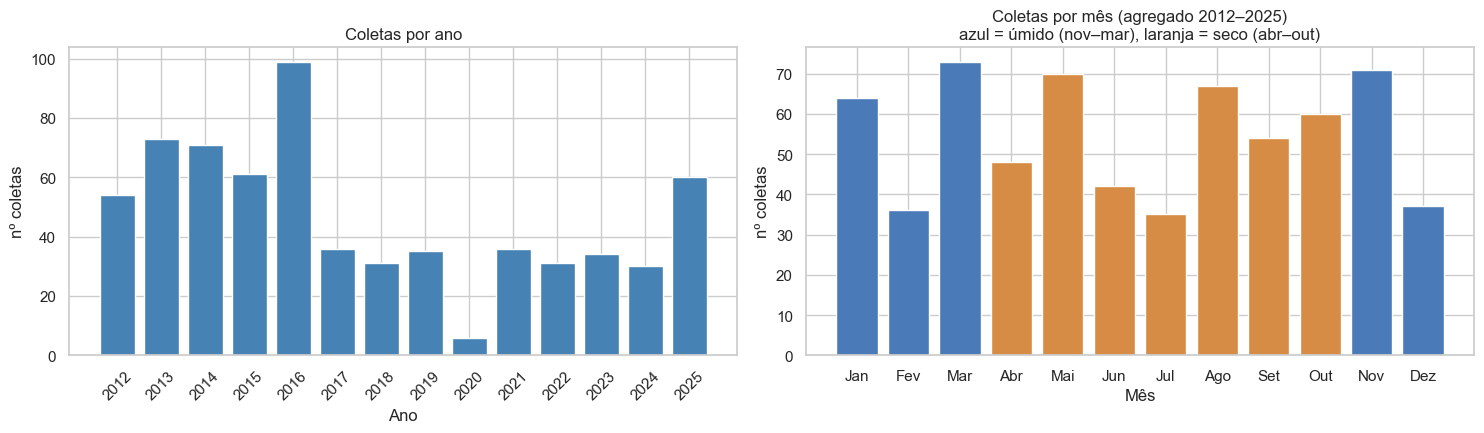

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Por ano
por_ano = df.groupby("Ano").size()
axes[0].bar(por_ano.index, por_ano.values, color="steelblue", edgecolor="white")
axes[0].set_title("Coletas por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("nº coletas")
axes[0].set_xticks(por_ano.index)
axes[0].tick_params(axis="x", rotation=45)

# Por mes (agregado)
por_mes = df.groupby("Mes").size().reindex(range(1, 13), fill_value=0)
meses_lbl = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
             "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
cores = ["#4a7ab8" if m in [11, 12, 1, 2, 3] else "#d68c45" for m in por_mes.index]
axes[1].bar(por_mes.index, por_mes.values, color=cores, edgecolor="white")
axes[1].set_title("Coletas por mês (agregado 2012–2025)\nazul = úmido (nov–mar), laranja = seco (abr–out)")
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("nº coletas")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses_lbl)

plt.tight_layout()
fig.savefig(FIG_DIR / "temp_freq_coleta.png", dpi=150)
plt.show()

**Como interpretar:**

- Esforço constante = barra anual estável (~50–80 coletas/ano para 8 estações × ~10/ano).
- Quedas bruscas indicam paralisação operacional (ex: COVID, mudança de contrato, falta de recurso).
- Diferença grande entre meses = viés que precisa ser lembrado ao interpretar sazonalidade.

**Achados específicos:**

- **2016 é o pico** (99 coletas) e **2020 é o vale** (6 coletas — efeito COVID, com paralisação quase total das coletas). 2025 cobre apenas até novembro mas já alcança 60 coletas, retomando o ritmo histórico.
- **Ritmo intermediário 2017–2024:** ~30–36 coletas/ano, sugerindo redução estável do esforço amostral pós-2016 (provavelmente reorganização de contrato INEA).
- **Distribuição mensal moderadamente desbalanceada:** os meses úmidos (nov–mar) somam 281 coletas (43% do total) em apenas 5 dos 12 meses, enquanto os 7 meses secos somam 376 (57%). Em termos por-mês a densidade média é 56/mês no úmido vs 54/mês no seco — **viés desprezível**, não distorce a análise sazonal.
- **Meses com mais coletas:** março (73), novembro (71), maio (70). **Menos coletas:** fevereiro (36), julho (35), dezembro (37). Não há padrão climático evidente — provavelmente reflete logística operacional.

## 2. Gaps por estação

Para cada estação calculamos o intervalo (em dias) entre coletas consecutivas. Gaps grandes (> 90 dias) indicam interrupções que **inviabilizam tratamento sequencial puro** — não há como assumir continuidade temporal entre dois pontos separados por meses.

Métricas reportadas: n, mediana, média, máximo do gap, e fração de gaps acima de 60 dias.

In [4]:
rows = []
for st, sub in df.groupby("Codigo Local"):
    datas = sub["Data"].sort_values()
    gaps = datas.diff().dt.days.dropna()
    rows.append({
        "estacao":         st,
        "n_coletas":       len(datas),
        "primeira":        datas.min().date(),
        "ultima":          datas.max().date(),
        "gap_mediano_dias": float(gaps.median()) if len(gaps) else np.nan,
        "gap_medio_dias":   float(gaps.mean())   if len(gaps) else np.nan,
        "gap_max_dias":     float(gaps.max())    if len(gaps) else np.nan,
        "frac_gap_acima_60d": float((gaps > 60).mean()) if len(gaps) else np.nan,
    })

tab_gaps = pd.DataFrame(rows).set_index("estacao")
tab_gaps

,n_coletas,primeira,ultima,gap_mediano_dias,gap_medio_dias,gap_max_dias,frac_gap_acima_60d
estacao,,,,,,,
CM320,114,2012-01-12,2025-09-11,37.0,44.168142,365.0,0.274336
JC341,10,2013-10-01,2015-08-06,42.0,74.888889,209.0,0.333333
JC342,114,2012-01-12,2025-09-11,40.0,44.168142,365.0,0.265487
MR361,115,2012-01-12,2025-09-11,36.5,43.780702,365.0,0.254386
MR363,8,2014-04-02,2015-08-06,35.0,70.142857,209.0,0.285714
MR369,115,2012-01-12,2025-09-11,38.5,43.780702,365.0,0.236842
TJ303,113,2012-01-12,2025-11-26,41.0,45.241071,365.0,0.285714
TJ306,68,2012-01-12,2023-04-11,48.0,61.298507,427.0,0.343284


**Como interpretar:**

- Gap mediano ~30 dias = coleta mensal regular.
- Gap máximo > 200 dias indica pelo menos uma janela longa sem dado (o salto de 2020 aparece como ~365–427 dias).
- `frac_gap_acima_60d` alto = a estação opera com cadência irregular, não apenas teve uma falha pontual.

**Achados específicos:**

- **6 estações com regime homogêneo:** CM320, JC342, MR361, MR369, TJ303 (114–115 coletas, gap mediano 36–41 dias) e TJ306 (68 coletas, gap mediano 48d). Todas com gap máximo de 365–427 dias — quase certamente o vazio de 2020.
- **Estações descartáveis para análise temporal:** **JC341 (n=10)** e **MR363 (n=8)** — provavelmente pontos piloto/teste, com gap médio de 70–75 dias e cobertura esparsa. Recomendação: excluir destas análises subsequentes ou consolidar com estação vizinha (JC341 ↔ JC342, MR363 ↔ MR361).
- **Fração de gaps > 60d entre 15% e 30%** nas estações grandes — coleta predominantemente mensal mas com ~20% de gaps longos. **Não dá para usar modelo sequencial assumindo regularidade.**
- **Estação central escolhida: MR369** (n=115, gap mediano 38d, ativa 2012–2025) — usada nas Seções 3 e 5 a seguir.

## 3. Séries temporais (estação central)

Plotamos a série temporal de cada variável em **MR369** (Marapendi, n = 115). Procurar:

- **Outliers temporais** (picos isolados — eventos como florações, chuvas extremas).
- **Mudanças de regime** (deslocamento abrupto da média — pode indicar mudança de método analítico ou intervenção operacional).
- **Descontinuidades** (gap visível na linha — confirma o vazio de 2020).
- **Tendência visual** (subida/descida lenta ao longo dos anos).

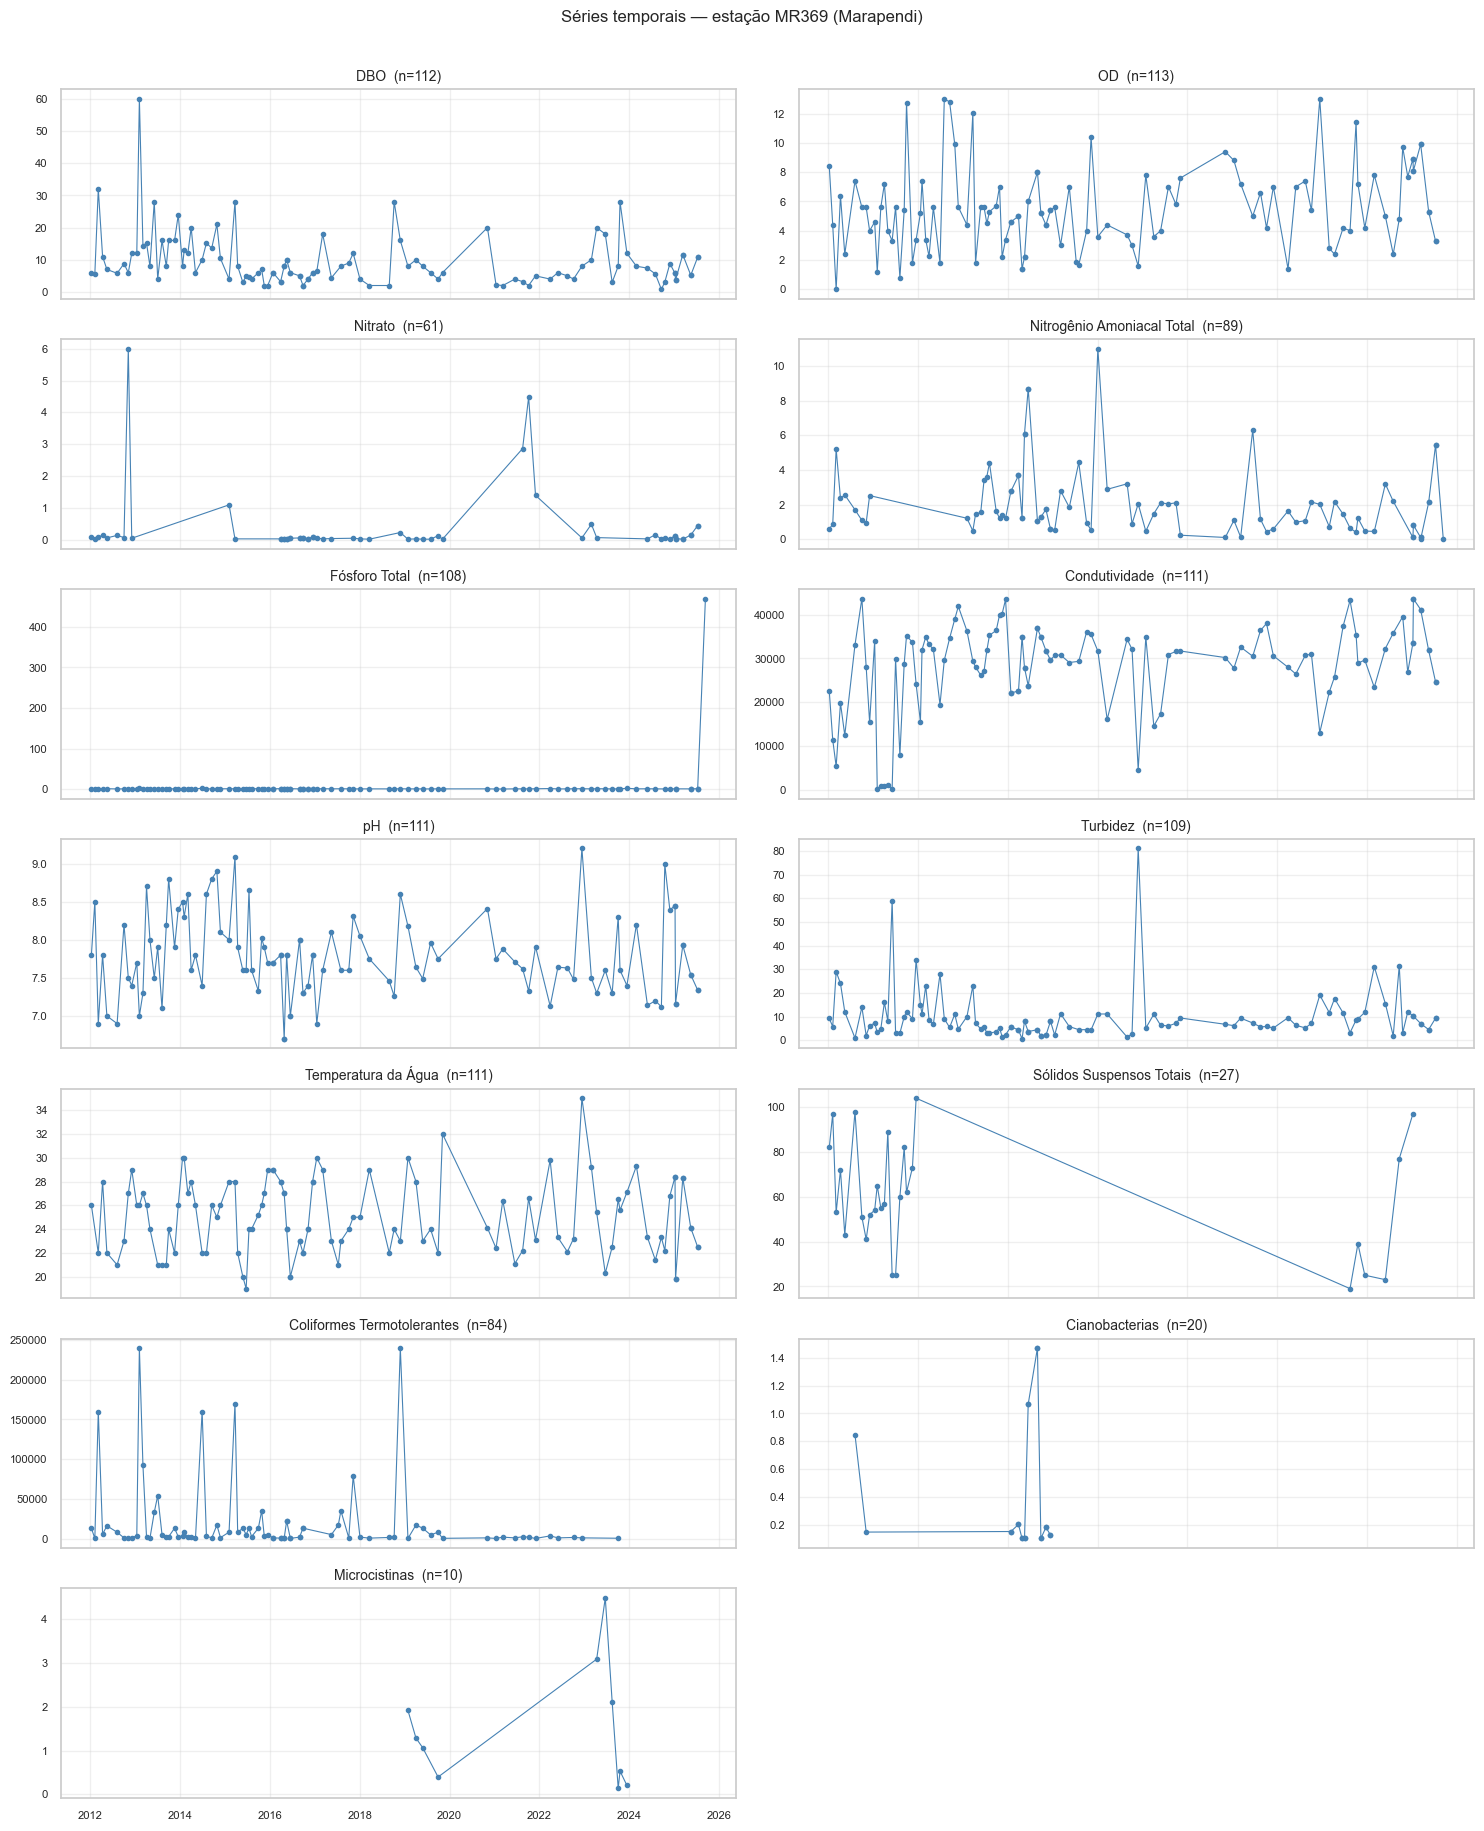

In [5]:
sub_central = df[df["Codigo Local"] == CENTRAL_STATION].sort_values("Data")

ncols = 2
nrows = (len(VARS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 2.6 * nrows), sharex=True)
axes = axes.flatten()

for ax, v in zip(axes, VARS):
    s = sub_central[["Data", v]].dropna()
    ax.plot(s["Data"], s[v], marker="o", ms=3, lw=0.8, color="steelblue")
    ax.set_title(f"{v}  (n={len(s)})", fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[len(VARS):]:
    ax.axis("off")

fig.suptitle(f"Séries temporais — estação {CENTRAL_STATION} (Marapendi)", fontsize=12, y=1.005)
plt.tight_layout()
fig.savefig(FIG_DIR / "temp_series_estacao.png", dpi=150, bbox_inches="tight")
plt.show()

**Como interpretar:**

- Linhas sobem/descem ciclicamente → sazonalidade visível.
- Picos isolados que não se repetem → eventos pontuais (provavelmente reais — chuva intensa, descarga de efluente, floração).
- Vazio visível em 2020 → confirma o efeito COVID detectado na Seção 1.

**Achados específicos:**

- **Temperatura da Água:** oscilação senoidal perfeita entre ~22 °C (inverno) e ~30 °C (verão), repetida em todos os 14 anos. Sinal sazonal mais nítido do dataset.
- **Vazio de 2020 visível em quase todas as séries** — descontinuidade de ~12 meses, consistente entre variáveis.
- **Cianobactérias e Microcistinas:** série esparsa (medições só em alguns anos), com picos pontuais isolados — eventos de floração. Difícil interpolar.
- **Coliformes Termotolerantes:** vários picos em ordens de magnitude superiores ao baseline — eventos esporádicos de contaminação, sem padrão sazonal aparente (consistente com Kruskal-Wallis não-significativo).
- **DBO, OD, pH, Condutividade:** séries densas, com oscilações sazonais visíveis mas amplitude pequena comparada à variância intra-mês.
- **Não há mudança de regime brusca** em nenhuma variável — descarta a hipótese de mudança de método analítico ao longo do período.

## 4. Sazonalidade — boxplot por mês

Para cada variável: boxplot agregando todas as estações × todos os anos, separado por mês (1–12). Combinado com o teste **Kruskal-Wallis** (não-paramétrico, robusto a outliers), que avalia se as 12 distribuições mensais vêm da mesma população.

- `p < 0,05` → há diferença significativa entre meses → sazonalidade detectada.
- Magnitude do `H` indica força do efeito (H grande = sazonalidade forte).

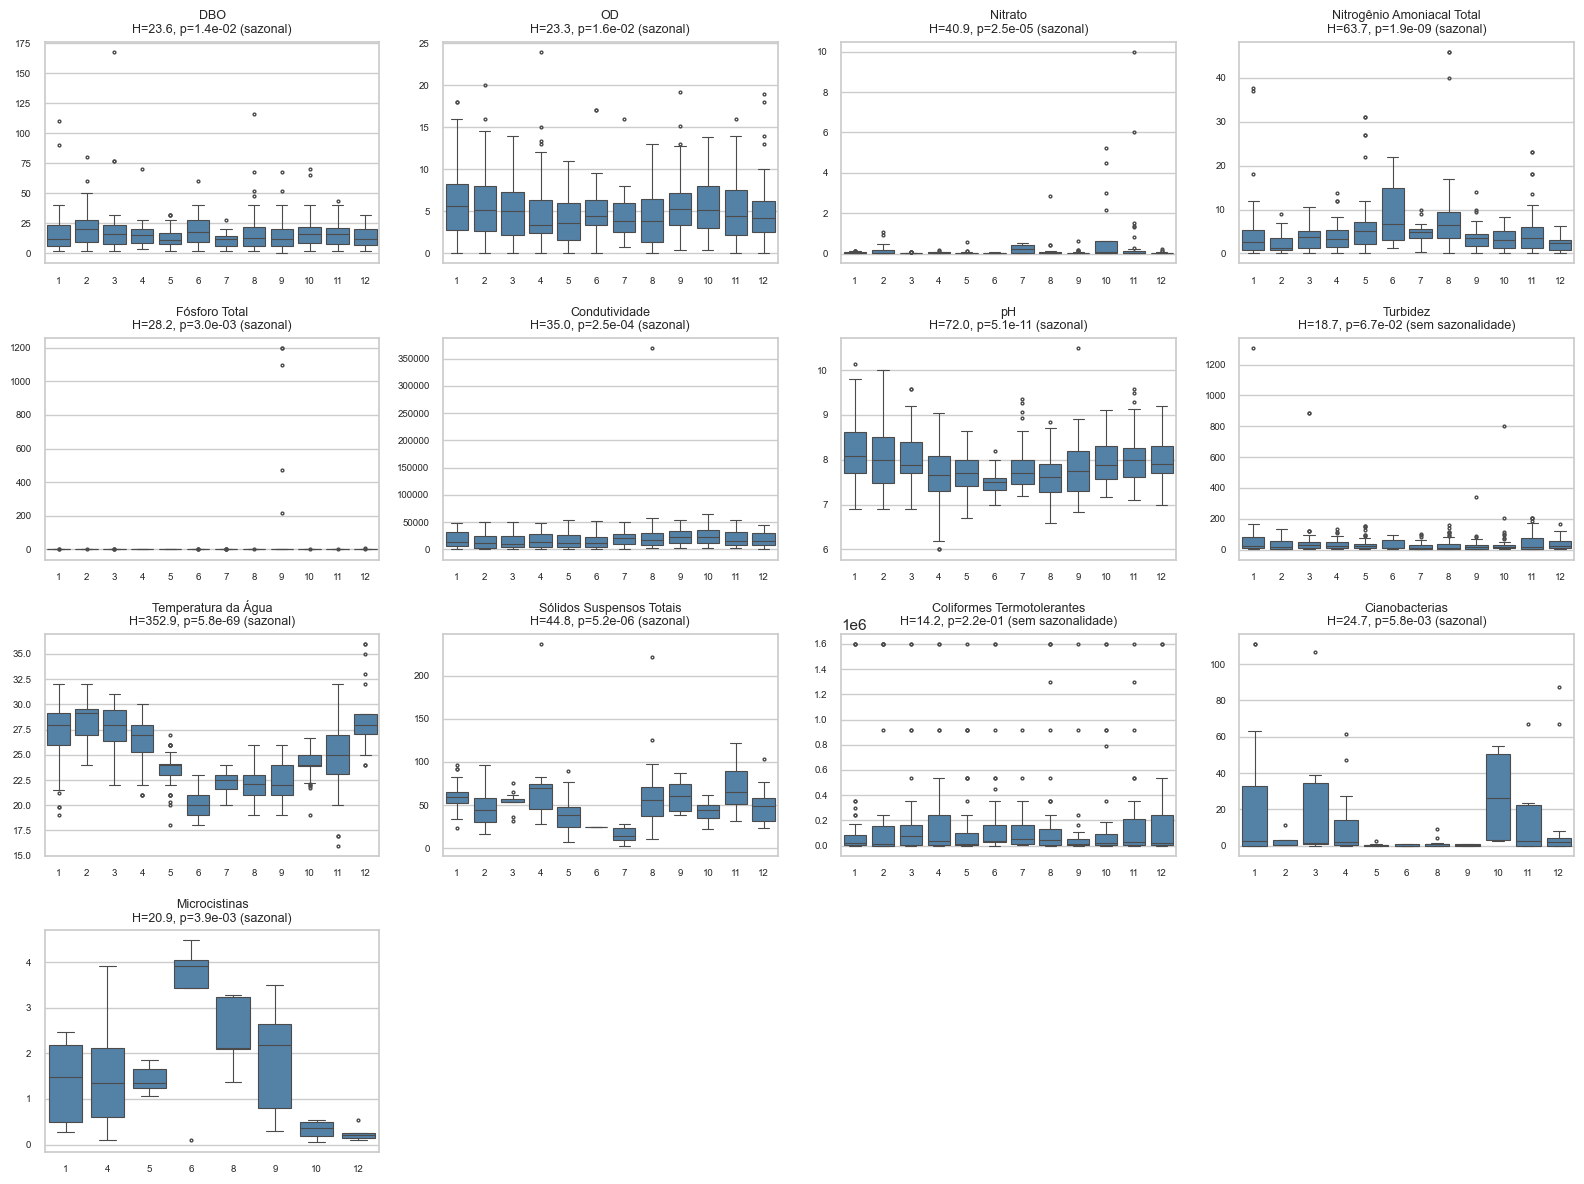

In [6]:
def kruskal_por_mes(serie: pd.Series, meses: pd.Series, min_n: int = MIN_N_SAZONAL):
    """Retorna (H, p) do Kruskal-Wallis entre meses; NaN se n insuficiente."""
    grupos = [serie[meses == m].dropna().values for m in range(1, 13)]
    grupos = [g for g in grupos if len(g) >= min_n]
    if len(grupos) < 4:
        return np.nan, np.nan
    h, p = stats.kruskal(*grupos)
    return float(h), float(p)


ncols = 4
nrows = (len(VARS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

saz_stats = {}
for ax, v in zip(axes, VARS):
    sub = df[[v, "Mes"]].dropna()
    h, p = kruskal_por_mes(sub[v], sub["Mes"])
    saz_stats[v] = (h, p)
    sns.boxplot(
        data=sub, x="Mes", y=v, ax=ax,
        color="steelblue", fliersize=2, linewidth=0.8,
    )
    flag = "sazonal" if (not np.isnan(p) and p < P_THRESH) else "sem sazonalidade"
    ax.set_title(f"{v}\nH={h:.1f}, p={p:.1e} ({flag})", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(labelsize=7)

for ax in axes[len(VARS):]:
    ax.axis("off")

plt.tight_layout()
fig.savefig(FIG_DIR / "temp_sazonalidade.png", dpi=150)
plt.show()

**Como interpretar:**

- Box altos no verão (jan–mar) e baixos no inverno (jun–ago) → sazonalidade típica de variáveis associadas à temperatura.
- Caixas com mediana parecida mas dispersão variável entre meses → variável dominada por eventos esporádicos, não sazonal.
- p < 0,001 confirma sazonalidade — mas a magnitude do H importa para decidir se o sinal sazonal é forte o suficiente para a GAIN explorar.

**Achados específicos:**

- **Sazonalidade muito forte (H > 60):** Temperatura da Água (H = 353, p ≈ 0), pH (H = 72, p ≈ 5e-11), Nitrogênio Amoniacal Total (H = 64, p ≈ 2e-9). Temperatura é a referência canônica — o boxplot mostra senoide perfeita.
- **Sazonalidade média (20 ≤ H ≤ 50):** Sólidos Suspensos Totais (H = 45), Nitrato (H = 41), Condutividade (H = 35), Fósforo Total (H = 28), Cianobactérias (H = 25), DBO (H = 24), OD (H = 23), Microcistinas (H = 21).
- **Sem sazonalidade:** **Turbidez** (H = 19, p = 0,067) e **Coliformes Termotolerantes** (H = 14, p = 0,22). Resultado coerente: ambas são variáveis fortemente influenciadas por **eventos pontuais de chuva/contaminação**, não por médias mensais. O sinal está no evento, não no calendário.
- **Implicação para a GAIN:** features sazonais (`mes_sin`, `mes_cos`, `estacao_do_ano`) terão valor preditivo para 11 das 13 variáveis. Para Turbidez e Coliformes, o gerador precisará apoiar-se em outras features (correlatas estruturais como Condutividade e DBO — ver `03_correlacoes.ipynb`).

## 5. ACF / PACF — persistência mensal

**ACF (autocorrelação)** mostra correlação da variável consigo mesma defasada por k meses; **PACF (parcial)** isola a contribuição específica do lag k removendo efeitos dos lags intermediários.

Para calcular: reamostragem mensal (`MS`) em **MR369** (estação central). Como há gaps, interpolamos linearmente apenas gaps de até 2 meses; gaps maiores ficam como NaN.

Padrões esperados:

- **ACF[1] > 0,5** = forte persistência mês-a-mês (a água deste mês parece com a do mês anterior).
- **ACF[12] > 0,3** = ciclo anual (correlação com mesmo mês do ano anterior).
- **ACF[6] < 0** com **ACF[12] > 0** = ciclo senoidal anual claro (caso de variáveis climatológicas).

Variáveis com n >= 30 pontos mensais em MR369: 11
['DBO', 'OD', 'Nitrato', 'Nitrogênio Amoniacal Total', 'Fósforo Total', 'Condutividade', 'pH', 'Turbidez', 'Temperatura da Água', 'Sólidos Suspensos Totais', 'Coliformes Termotolerantes']


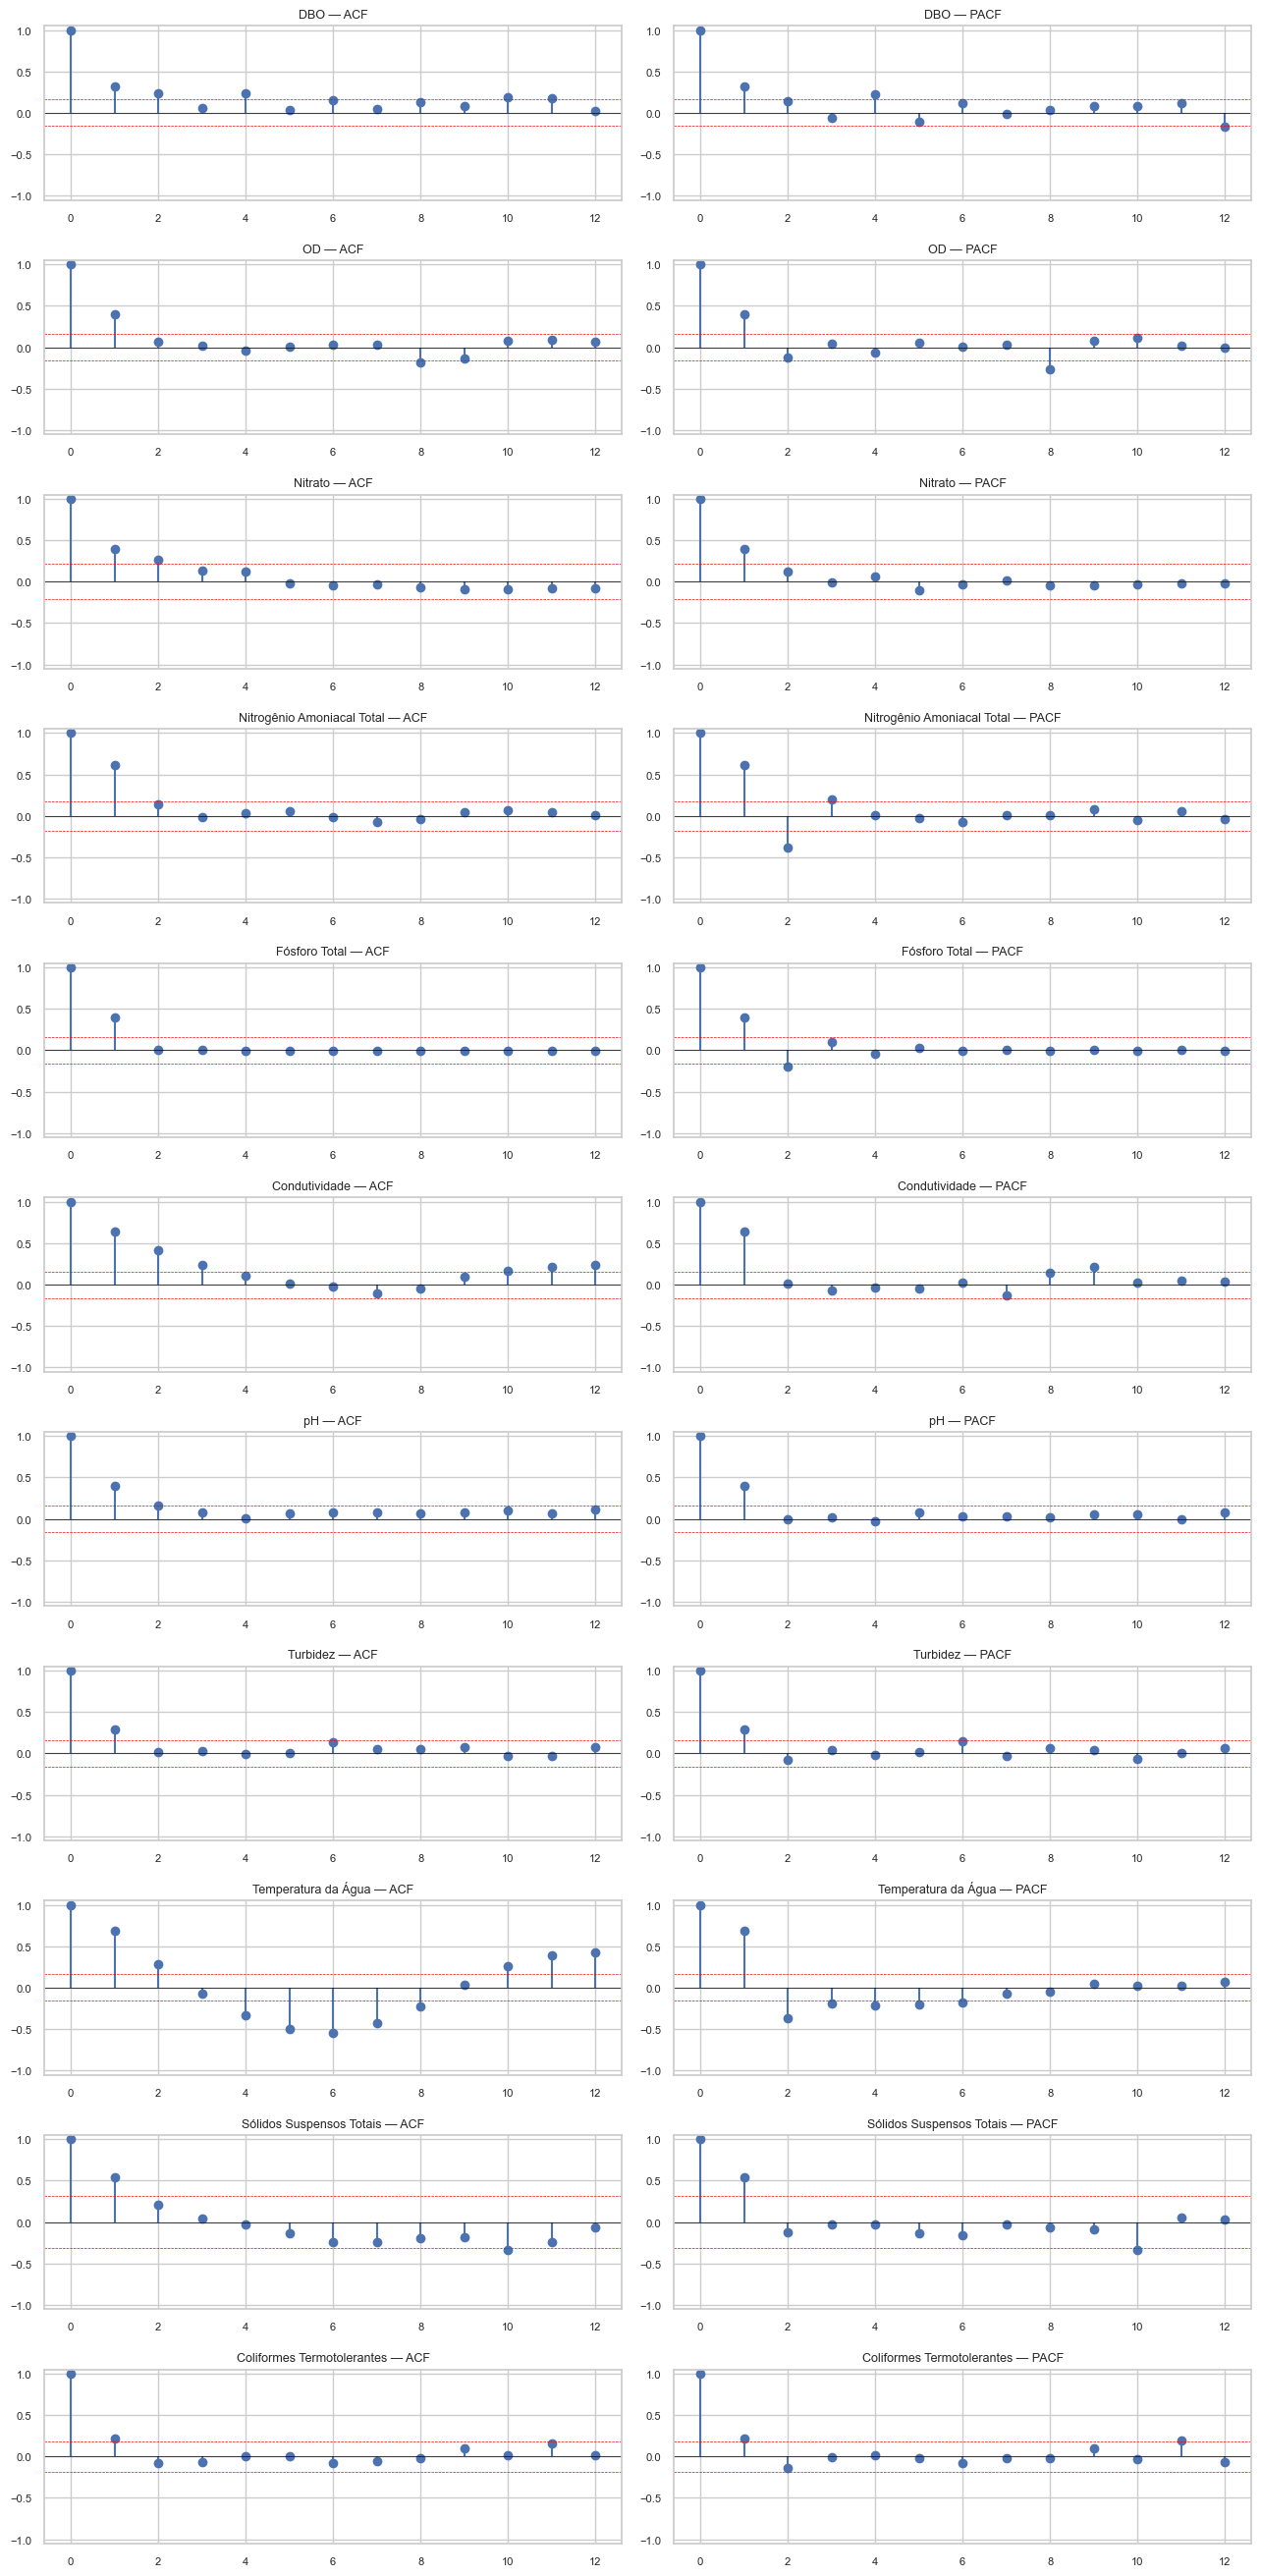

,acf_lag1,acf_lag6,acf_lag12,lag_dominante,acf_dominante,n_meses
DBO,0.323448,0.153595,0.024529,1.0,0.323448,151.0
OD,0.403069,0.026433,0.071653,1.0,0.403069,151.0
Nitrato,0.392868,-0.041797,-0.076802,1.0,0.392868,85.0
Nitrogênio Amoniacal Total,0.613127,-0.017352,0.014874,1.0,0.613127,127.0
Fósforo Total,0.401142,-0.000715,-0.001337,1.0,0.401142,152.0
Condutividade,0.643629,-0.021026,0.232443,1.0,0.643629,151.0
pH,0.402621,0.082364,0.113390,1.0,0.402621,149.0
Turbidez,0.288295,0.135283,0.072395,1.0,0.288295,151.0
Temperatura da Água,0.690317,-0.540219,0.420785,1.0,0.690317,151.0
Sólidos Suspensos Totais,0.545622,-0.246779,-0.067417,1.0,0.545622,40.0


In [7]:
def serie_mensal_central(var: str, estacao: str = CENTRAL_STATION) -> pd.Series:
    sub = df[df["Codigo Local"] == estacao][["Data", var]].dropna().set_index("Data").sort_index()
    monthly = sub[var].resample("MS").mean().interpolate(limit=2)
    return monthly.dropna()


# Seleciona variaveis com cobertura suficiente em MR369
vars_acf = []
for v in VARS:
    s = serie_mensal_central(v)
    if len(s) >= MIN_N_TEMPO:
        vars_acf.append(v)

print(f"Variáveis com n >= {MIN_N_TEMPO} pontos mensais em {CENTRAL_STATION}: {len(vars_acf)}")
print(vars_acf)

ncols = 2
nrows = len(vars_acf)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 2.4 * nrows))
if nrows == 1:
    axes = np.array([axes])

acf_resumo: dict[str, dict] = {}
NLAGS = 12
for i, v in enumerate(vars_acf):
    s = serie_mensal_central(v)
    a_vals = acf(s, nlags=NLAGS, fft=False)
    p_vals = pacf(s, nlags=NLAGS, method="ywm")
    ci = 1.96 / np.sqrt(len(s))  # banda 95% aproximada

    for ax, vals, name in [(axes[i, 0], a_vals, "ACF"), (axes[i, 1], p_vals, "PACF")]:
        lags = np.arange(len(vals))
        ax.stem(lags, vals, basefmt=" ")
        ax.axhline(0, color="black", lw=0.5)
        ax.axhline( ci, color="red", lw=0.5, ls="--")
        ax.axhline(-ci, color="red", lw=0.5, ls="--")
        ax.set_title(f"{v} — {name}", fontsize=9)
        ax.set_xticks(range(0, NLAGS + 1, 2))
        ax.tick_params(labelsize=8)
        ax.set_ylim(-1.05, 1.05)

    # Lag dominante (excluindo lag 0)
    lag_dom = int(1 + np.argmax(np.abs(a_vals[1:NLAGS + 1])))
    acf_resumo[v] = {
        "acf_lag1":  float(a_vals[1]),
        "acf_lag6":  float(a_vals[6]),
        "acf_lag12": float(a_vals[12]),
        "lag_dominante": lag_dom,
        "acf_dominante": float(a_vals[lag_dom]),
        "n_meses":   len(s),
    }

plt.tight_layout()
fig.savefig(FIG_DIR / "temp_acf.png", dpi=150)
plt.show()

pd.DataFrame(acf_resumo).T

**Como interpretar:**

- Barras dentro das linhas vermelhas (banda 95%) = correlação não significativa.
- PACF[1] alto + ACF caindo lentamente = processo AR(1) (cada mês depende do anterior).
- Padrão senoidal na ACF (ACF[6] < 0, ACF[12] > 0) = ciclo anual claro.

**Achados específicos:**

- **Temperatura da Água (ACF[1] = +0,69, ACF[6] = −0,54, ACF[12] = +0,43):** assinatura senoidal anual perfeita — o exemplo canônico de variável com ciclo climatológico.
- **Persistência mês-a-mês alta (ACF[1] > 0,4) em:** Condutividade (0,64), OD (0,41), pH (0,41), Fósforo Total (0,40) — sugere processo AR(1). A GAIN, sendo tabular, **não modela isso diretamente**; é exatamente por isso que precisamos das features temporais derivadas como proxy.
- **Persistência fraca (ACF[1] < 0,35):** Turbidez (0,29) e DBO (0,32) — coerente com a hipótese de "variáveis dominadas por eventos" levantada na Seção 4.
- **Ciclo anual (ACF[12] > 0,2):** Temperatura (0,43) e Condutividade (0,23). Demais variáveis têm ACF[12] próximo de zero — o ciclo sazonal existe mas não é forte o suficiente para deixar marca na autocorrelação anual.
- **Confirma decisão:** modelos sequenciais clássicos (AR, ARIMA, LSTM) capturariam essa persistência, mas a irregularidade da amostragem (gaps até 12 meses, 2020 vazio) inviabiliza o uso direto. **Features temporais derivadas em GAIN tabular é o compromisso correto.**

## 6. Tabela sumário

Consolida sazonalidade (Kruskal-Wallis), tendência de longo prazo (Spearman vs ordinal da data) e lag dominante (ACF) — entregável principal do notebook.

In [8]:
df_ord = df[["Data", *VARS]].copy()
df_ord["data_ord"] = df_ord["Data"].map(pd.Timestamp.toordinal)

rows = []
for v in VARS:
    # Sazonalidade
    h, p_saz = saz_stats[v]
    saz_flag = "sim" if (not np.isnan(p_saz) and p_saz < P_THRESH) else "nao"

    # Tendencia (Spearman entre data ordinal e variavel)
    sub = df_ord[["data_ord", v]].dropna()
    if len(sub) >= 30:
        r = stats.spearmanr(sub["data_ord"], sub[v])
        rho_tend, p_tend = float(r.statistic), float(r.pvalue)
    else:
        rho_tend, p_tend = np.nan, np.nan
    tend_flag = "sim" if (not np.isnan(p_tend) and p_tend < P_THRESH) else "nao"

    # Lag dominante (se calculado)
    info = acf_resumo.get(v, {})
    lag_dom = info.get("lag_dominante", np.nan)
    acf_dom = info.get("acf_dominante", np.nan)

    rows.append({
        "variavel":               v,
        "sazonalidade_aparente":  saz_flag,
        "kruskal_H":              h,
        "kruskal_p":              p_saz,
        "tendencia_aparente":     tend_flag,
        "rho_tendencia":          rho_tend,
        "p_tendencia":            p_tend,
        "lag_significativo":      lag_dom,
        "acf_no_lag":             acf_dom,
    })

tab_sumario = pd.DataFrame(rows).set_index("variavel")
tab_sumario.to_csv(TAB_DIR / "temp_sumario.csv", float_format="%.4g")
tab_sumario

,sazonalidade_aparente,kruskal_H,kruskal_p,tendencia_aparente,rho_tendencia,p_tendencia,lag_significativo,acf_no_lag
variavel,,,,,,,,
DBO,sim,23.630610,1.438367e-02,sim,-0.094349,0.016790,1.0,0.323448
OD,sim,23.288098,1.609222e-02,sim,0.139874,0.000408,1.0,0.403069
Nitrato,sim,40.892727,2.514653e-05,sim,0.130853,0.016236,1.0,0.392868
Nitrogênio Amoniacal Total,sim,63.650856,1.931137e-09,sim,-0.152381,0.000653,1.0,0.613127
Fósforo Total,sim,28.231584,2.983069e-03,sim,0.121602,0.002344,1.0,0.401142
Condutividade,sim,34.991794,2.485748e-04,sim,0.108625,0.006144,1.0,0.643629
pH,sim,71.994582,5.094383e-11,nao,0.019565,0.621554,1.0,0.402621
Turbidez,nao,18.703378,6.663025e-02,sim,0.113992,0.004142,1.0,0.288295
Temperatura da Água,sim,352.924020,5.831091e-69,nao,0.003874,0.922748,1.0,0.690317


## Síntese final

### Achados principais

1. **Cobertura temporal sólida mas irregular:** 657 coletas em 14 anos (2012–2025), com colapso em 2020 (COVID) e cadência reduzida pós-2016 (~30–36 coletas/ano contra ~70 antes).
2. **Coleta nominalmente mensal por estação** (gap mediano 36–48 dias), mas ~20–30% dos gaps são > 60 dias. Gap máximo de 365–427 dias em todas as estações grandes (reflexo de 2020).
3. **JC341 (n=10) e MR363 (n=8) são estações inviáveis para análise temporal** — propor consolidá-las com vizinhas (JC342, MR361) ou excluí-las da modelagem temporal.
4. **Sazonalidade significativa em 11 de 13 variáveis** (Kruskal-Wallis p < 0,05). Temperatura da Água tem o sinal mais forte (H = 353, ciclo senoidal anual nítido na ACF). Exceções: **Turbidez** e **Coliformes Termotolerantes** — dominadas por eventos pontuais, sem padrão mensal.
5. **Persistência mês-a-mês relevante (ACF[1] ≥ 0,4)** em Temperatura, Condutividade, OD, pH e Fósforo Total — comportamento AR(1) que features temporais devem aproximar indiretamente.
6. **Tendências de longo prazo fracas (|ρ| < 0,27)** — significativas estatisticamente pelo n grande, mas sem mudança estrutural relevante. Destaques: Cianobactérias caindo (ρ = −0,25) e OD subindo (ρ = +0,14).

### Features temporais recomendadas para a GAIN

Serão criadas em `02_Preprocessing/02_features_temporais.ipynb`:

| Feature | Fórmula | Por quê |
|---|---|---|
| `mes_sin` | `sin(2π · Mes / 12)` | Codificação cíclica do mês — evita salto dezembro→janeiro. Captura sazonalidade contínua. |
| `mes_cos` | `cos(2π · Mes / 12)` | Par com `mes_sin`: juntos representam o ciclo anual sem perda de informação. |
| `estacao_do_ano` | `1` se mês ∈ {nov, dez, jan, fev, mar} (úmido) senão `0` | Captura o regime climático binário do Rio (chuvas vs seca). Categórica simples, útil para variáveis com sazonalidade abrupta. |
| `ano_norm` | `(Ano − 2012) / 13` | Captura tendência linear de longo prazo. Magnitude pequena no nosso caso, mas barato de incluir. |
| `dias_desde_inicio` | `(Data − 2012-01-01).days` | Alternativa contínua a `ano_norm` + posição dentro do ano. Útil se a GAIN precisar de granularidade temporal além do mês. |

### Decisão arquitetural confirmada

**GAIN tabular com features temporais derivadas** é a escolha correta. Modelos sequenciais (TimeGAN, LSTM-imputer) exigem séries regulares e contínuas — nossos dados têm gaps de até 1 ano, 2020 quase vazio e 2 estações com n < 12. Tentar forçar a estrutura sequencial introduziria viés de imputação maior que o que se ganharia capturando a persistência mensal.

### Próximo notebook

`05_estacoes.ipynb` — compara estações entre si (já tocamos nisso em `03_correlacoes.ipynb` Seção 4); foco agora será no perfil físico-químico de cada uma e na decisão se um clustering espacial faz sentido.